# Quiz: Stochastic Processes Simulations

This notebook simulates and compares three discrete-time stochastic systems:
1. AWGN filtered by a low-pass system $H(\omega)$
2. ARMA(3, 6) process
3. Random Walk process

Each process is represented with the same `StochasticProcess` dataclass and visualized in three domains: realization in $t$, autocorrelation in $\tau$, and PSD in $\omega$.


In [11]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import torch


@dataclass(frozen=True)
class StochasticProcess:
    """Stores one realization and its lag/frequency-domain summaries."""

    realization: np.ndarray  # Process samples x[t] [a.u.]
    acf: tuple[np.ndarray, np.ndarray]  # (tau_samples, R_x[tau])
    psd: tuple[np.ndarray, np.ndarray]  # (omega_rad, S_x[omega])


@dataclass(frozen=True)
class ProcessSpecification:
    """Defines one process model and all parameters needed to simulate it."""

    name: str
    family: Literal["filtered_awgn", "arma", "random_walk"]
    ar_coeffs: np.ndarray | None = None   # AR coefficients for ARMA [a1, ..., ap]
    ma_coeffs: np.ndarray | None = None   # MA coefficients for ARMA [b1, ..., bq]
    cutoff_rad: float | None = None       # LPF cutoff [rad/sample]
    num_taps: int = 41                    # FIR length [samples]
    noise_std: float = 1.0                # Innovation std (ARMA/AWGN)
    step_std: float = 1.0                 # Random-walk increment std
    burn_in_samples: int = 500            # Warm-up samples for ARMA


@dataclass(frozen=True)
class ProcessDiagnostics:
    """Stores theoretical admissibility checks for one process model."""

    is_wss: bool
    ar_stable: bool | None
    ma_invertible: bool | None
    ar_root_moduli: np.ndarray            # |roots| of AR polynomial
    ma_root_moduli: np.ndarray            # |roots| of MA polynomial
    rationale: str                        # Short theoretical note


def ar_characteristic_roots(
    ar_coeffs: np.ndarray,                    # AR coefficients [a1, ..., ap]
) -> np.ndarray:                              # Roots of 1 - a1 z - ... - ap z^p
    """Return roots of the AR polynomial used for stationarity checks."""
    ar_array = np.asarray(ar_coeffs, dtype=np.float64)
    if ar_array.size == 0:
        return np.empty(0, dtype=np.complex128)

    # For x[t] = sum_k a_k x[t-k] + w[t], stationarity requires roots of
    # 1 - a1 z - ... - ap z^p = 0 outside the unit circle.
    # np.roots expects descending powers: [-ap, ..., -a1, 1].
    poly_coeffs = np.concatenate((-ar_array[::-1], [1.0]))
    return np.roots(poly_coeffs)


def ma_characteristic_roots(
    ma_coeffs: np.ndarray,                    # MA coefficients [b1, ..., bq]
) -> np.ndarray:                              # Roots of 1 + b1 z + ... + bq z^q
    """Return roots of the MA polynomial used for invertibility checks."""
    ma_array = np.asarray(ma_coeffs, dtype=np.float64)
    if ma_array.size == 0:
        return np.empty(0, dtype=np.complex128)

    # For B(z)=1 + b1 z + ... + bq z^q, invertibility requires roots
    # outside the unit circle. np.roots expects descending powers.
    poly_coeffs = np.concatenate((ma_array[::-1], [1.0]))
    return np.roots(poly_coeffs)


def check_ar_stability(
    ar_coeffs: np.ndarray,                    # AR coefficients [a1, ..., ap]
) -> tuple[bool, np.ndarray]:                # (all_roots_outside_unit_circle, |roots|)
    """Check AR stability/stationarity through the AR polynomial root moduli."""
    roots = ar_characteristic_roots(ar_coeffs)
    if roots.size == 0:
        return True, np.empty(0, dtype=np.float64)

    root_moduli = np.abs(roots)
    return bool(np.all(root_moduli > 1.0)), root_moduli


def check_ma_invertibility(
    ma_coeffs: np.ndarray,                    # MA coefficients [b1, ..., bq]
) -> tuple[bool, np.ndarray]:                # (all_roots_outside_unit_circle, |roots|)
    """Check MA invertibility through the MA polynomial root moduli."""
    roots = ma_characteristic_roots(ma_coeffs)
    if roots.size == 0:
        return True, np.empty(0, dtype=np.float64)

    root_moduli = np.abs(roots)
    return bool(np.all(root_moduli > 1.0)), root_moduli


def evaluate_theoretical_diagnostics(
    specification: ProcessSpecification,       # Model configuration to validate
) -> ProcessDiagnostics:                      # WSS/stability/invertibility summary
    """Evaluate admissibility constraints from the noise_models framework.

    Purpose:
        Apply a model-first validation policy before simulation:
        - AR poles outside unit circle for stationarity.
        - MA zeros outside unit circle for invertibility.
        - Random walk explicit non-WSS classification.

    Parameters:
        specification: Process descriptor with process family and parameters.

    Returns:
        ProcessDiagnostics containing WSS/stability/invertibility outcomes and
        root-modulus vectors used to justify each decision.

    Side effects:
        None.

    Assumptions:
        Coefficient arrays are one-dimensional when provided.
    """
    empty = np.empty(0, dtype=np.float64)

    if specification.family == "filtered_awgn":
        if specification.cutoff_rad is None:
            raise ValueError(f"{specification.name}: cutoff_rad is required for filtered_awgn.")
        return ProcessDiagnostics(
            is_wss=True,
            ar_stable=None,
            ma_invertible=None,
            ar_root_moduli=empty,
            ma_root_moduli=empty,
            rationale="Stable FIR driven by white noise -> WSS output.",
        )

    if specification.family == "arma":
        if specification.ar_coeffs is None or specification.ma_coeffs is None:
            raise ValueError(f"{specification.name}: both ar_coeffs and ma_coeffs are required.")

        ar_stable, ar_moduli = check_ar_stability(specification.ar_coeffs)
        ma_invertible, ma_moduli = check_ma_invertibility(specification.ma_coeffs)
        return ProcessDiagnostics(
            is_wss=ar_stable,
            ar_stable=ar_stable,
            ma_invertible=ma_invertible,
            ar_root_moduli=ar_moduli,
            ma_root_moduli=ma_moduli,
            rationale=(
                "ARMA is WSS when AR roots satisfy |z| > 1; "
                "invertibility additionally requires MA roots with |z| > 1."
            ),
        )

    if specification.family == "random_walk":
        return ProcessDiagnostics(
            is_wss=False,
            ar_stable=False,
            ma_invertible=None,
            ar_root_moduli=np.array([1.0], dtype=np.float64),
            ma_root_moduli=empty,
            rationale="Unit root at z=1 -> non-WSS level process.",
        )

    raise ValueError(f"Unsupported process family: {specification.family}")


def enforce_admissibility(
    specification: ProcessSpecification,       # Model configuration to validate
    diagnostics: ProcessDiagnostics,           # Precomputed theoretical checks
) -> None:                                    # Raises when assumptions are violated
    """Raise explicit errors when a specification violates modeling assumptions."""
    if specification.family == "arma" and diagnostics.ar_stable is False:
        moduli_str = np.array2string(diagnostics.ar_root_moduli, precision=4)
        raise ValueError(
            f"{specification.name}: non-stationary AR part (|roots|={moduli_str}). "
            "Adjust AR coefficients so all roots satisfy |z| > 1."
        )

    if specification.family == "arma" and diagnostics.ma_invertible is False:
        moduli_str = np.array2string(diagnostics.ma_root_moduli, precision=4)
        raise ValueError(
            f"{specification.name}: non-invertible MA part (|roots|={moduli_str}). "
            "Adjust MA coefficients so all roots satisfy |z| > 1."
        )


def welch_psd_torch(
    realization: np.ndarray,             # Input realization x[t]
    n_fft: int = 1024,                   # Number of FFT bins
    segment_length_samples: int = 256,   # Welch segment length [samples]
    overlap_samples: int = 128,          # Overlap between segments [samples]
) -> tuple[np.ndarray, np.ndarray]:      # (omega_rad, normalized_psd)
    """Estimate a two-sided Welch PSD using PyTorch FFT primitives.

    Purpose:
        Compute an averaged periodogram estimate with Hann windowing and
        overlapping segments, using PyTorch for the FFT pipeline.
    Parameters:
        realization: One-dimensional realization x[t].
        n_fft: Number of FFT bins.
        segment_length_samples: Welch window length [samples].
        overlap_samples: Overlap between adjacent windows [samples].
    Returns:
        `(omega_rad, psd_values)` where `omega_rad` is in [-pi, pi) and
        `psd_values` is normalized to unit maximum for comparison plots.
    Side effects:
        None.
    Assumptions:
        Input is real-valued and long enough for at least one Welch segment.
    """
    if realization.ndim != 1:
        raise ValueError("realization must be a 1-D array.")
    if n_fft < 16:
        raise ValueError("n_fft must be >= 16 for a meaningful PSD.")
    if segment_length_samples < 8:
        raise ValueError("segment_length_samples must be >= 8.")
    if overlap_samples < 0 or overlap_samples >= segment_length_samples:
        raise ValueError("overlap_samples must satisfy 0 <= overlap < segment_length.")

    num_samples = realization.size
    if num_samples <= segment_length_samples:
        raise ValueError("realization length must exceed segment_length_samples.")

    x_tensor = torch.as_tensor(realization, dtype=torch.float64)
    step_samples = segment_length_samples - overlap_samples

    # Build overlapping frames with index-based slicing for Welch averaging.
    segment_starts = torch.arange(
        0,
        num_samples - segment_length_samples + 1,
        step_samples,
        dtype=torch.int64,
    )
    if int(segment_starts.numel()) == 0:
        raise RuntimeError("Welch PSD failed: no valid segments were generated.")

    frame_offsets = torch.arange(segment_length_samples, dtype=torch.int64)
    frame_indices = segment_starts[:, None] + frame_offsets[None, :]
    segments = x_tensor[frame_indices]

    # Apply Hann window and average two-sided periodograms in the FFT domain.
    window = torch.hann_window(segment_length_samples, periodic=False, dtype=torch.float64)
    window_power = torch.sum(window**2).clamp_min(torch.finfo(torch.float64).eps)
    spectra = torch.fft.fft(segments * window.unsqueeze(0), n=n_fft, dim=1)
    periodograms = torch.abs(spectra) ** 2 / window_power
    psd_two_sided = torch.mean(periodograms, dim=0)

    # Shift to [-pi, pi) and normalize amplitude for consistent visualization.
    psd_shifted = torch.fft.fftshift(psd_two_sided)
    psd_values = psd_shifted / torch.max(psd_shifted).clamp_min(torch.finfo(torch.float64).eps)
    omega_rad = torch.linspace(-torch.pi, torch.pi, n_fft + 1, dtype=torch.float64)[:-1]

    return omega_rad.cpu().numpy(), psd_values.cpu().numpy()


def estimate_acf_psd(
    realization: np.ndarray,             # Process samples x[t]
    max_lag_samples: int = 128,          # Maximum lag for ACF [samples]
    n_fft: int = 1024,                   # Frequency bins for PSD estimation
    segment_length_samples: int = 256,   # Welch segment length [samples]
    overlap_samples: int = 128,          # Overlap between Welch segments [samples]
) -> tuple[tuple[np.ndarray, np.ndarray], tuple[np.ndarray, np.ndarray]]:
    """Estimate normalized ACF and Welch PSD from one realization.

    Purpose:
        Build an empirical autocorrelation around tau=0 and estimate the PSD
        with Welch's method (windowed averaged periodograms).
    Parameters:
        realization: One-dimensional realization x[t].
        max_lag_samples: Number of positive/negative lags to keep [samples].
        n_fft: Number of frequency samples for PSD discretization.
        segment_length_samples: Welch segment length [samples].
        overlap_samples: Overlap between adjacent Welch segments [samples].
    Returns:
        A pair `(acf, psd)` where:
        - `acf = (tau_samples, R_x[tau])` with normalized R_x[0] = 1.
        - `psd = (omega_rad, S_x[omega])` from Welch, normalized to max value 1.
    Side effects:
        None.
    Assumptions:
        Input is real-valued and long enough for requested lag and Welch window.
    """
    if realization.ndim != 1:
        raise ValueError("realization must be a 1-D array.")
    if max_lag_samples < 1:
        raise ValueError("max_lag_samples must be >= 1.")

    x_centered = realization - np.mean(realization)
    num_samples = x_centered.size

    # Compute full empirical autocorrelation and keep a symmetric lag window.
    acf_full = np.correlate(x_centered, x_centered, mode="full") / num_samples
    lags_full = np.arange(-num_samples + 1, num_samples)
    valid_lag_mask = np.abs(lags_full) <= min(max_lag_samples, num_samples - 1)
    tau_samples = lags_full[valid_lag_mask]
    acf_values = acf_full[valid_lag_mask]

    # Normalize ACF by zero-lag value for easier comparison across processes.
    acf_zero = float(acf_values[tau_samples == 0][0])
    acf_values = acf_values / max(acf_zero, np.finfo(float).eps)

    # Estimate Welch PSD through the dedicated PyTorch implementation.
    omega_rad, psd_values = welch_psd_torch(
        realization=x_centered,
        n_fft=n_fft,
        segment_length_samples=segment_length_samples,
        overlap_samples=overlap_samples,
    )

    return (tau_samples.astype(np.int64), acf_values), (omega_rad, psd_values)


def build_lowpass_fir(
    num_taps: int,                # Number of FIR taps
    cutoff_rad: float,            # Cutoff angular frequency [rad/sample]
) -> np.ndarray:                  # Low-pass FIR impulse response h[t]
    """Design a windowed-sinc low-pass FIR with unit gain at DC."""
    if num_taps % 2 == 0:
        raise ValueError("num_taps must be odd for linear-phase centering.")
    if not 0.0 < cutoff_rad < np.pi:
        raise ValueError("cutoff_rad must satisfy 0 < cutoff_rad < pi.")

    # Build an ideal low-pass and taper it with a Hamming window.
    n = np.arange(num_taps) - (num_taps - 1) / 2
    normalized_cutoff = cutoff_rad / np.pi
    h = normalized_cutoff * np.sinc(normalized_cutoff * n)
    h *= np.hamming(num_taps)

    # Normalize to keep DC gain equal to 1 after filtering.
    h /= np.sum(h)
    return h


def simulate_filtered_awgn(
    num_samples: int,             # Number of output samples
    rng: np.random.Generator,     # Random generator for reproducibility
    cutoff_rad: float,            # LPF cutoff [rad/sample]
    num_taps: int = 41,           # FIR length
    noise_std: float = 1.0,       # Input white-noise standard deviation
) -> np.ndarray:                  # Filtered AWGN realization x[t]
    """Generate AWGN passed through a low-pass FIR system H(omega)."""
    h = build_lowpass_fir(num_taps=num_taps, cutoff_rad=cutoff_rad)

    # Pad input noise so convolution can return exactly num_samples points.
    white_noise = noise_std * rng.standard_normal(num_samples + num_taps - 1)
    filtered_noise = np.convolve(white_noise, h, mode="valid")
    return filtered_noise[:num_samples]


def simulate_arma_process(
    num_samples: int,             # Number of output samples
    ar_coeffs: np.ndarray,        # AR coefficients [a1, ..., ap]
    ma_coeffs: np.ndarray,        # MA coefficients [b1, ..., bq]
    rng: np.random.Generator,     # Random generator for innovation noise
    noise_std: float = 1.0,       # Innovation standard deviation
    burn_in_samples: int = 500,   # Warm-up samples to reduce transients
) -> np.ndarray:                  # ARMA realization x[t]
    """Simulate x[t] = sum_k a_k x[t-k] + w[t] + sum_l b_l w[t-l]."""
    p_order = int(ar_coeffs.size)
    q_order = int(ma_coeffs.size)
    max_order = max(p_order, q_order)

    total_samples = num_samples + burn_in_samples + max_order
    innovations = noise_std * rng.standard_normal(total_samples)
    x = np.zeros(total_samples)

    # Recursively combine AR memory with MA colored innovation term.
    for idx in range(max_order, total_samples):
        ar_term = float(ar_coeffs @ x[idx - p_order:idx][::-1]) if p_order else 0.0
        ma_term = float(ma_coeffs @ innovations[idx - q_order:idx][::-1]) if q_order else 0.0
        x[idx] = ar_term + innovations[idx] + ma_term

    start_idx = burn_in_samples + max_order
    return x[start_idx:start_idx + num_samples]


def simulate_random_walk(
    num_samples: int,             # Number of output samples
    rng: np.random.Generator,     # Random generator for incremental noise
    step_std: float = 1.0,        # Step standard deviation
) -> np.ndarray:                  # Random walk realization x[t]
    """Generate a random walk by cumulative summation of Gaussian steps."""
    increments = step_std * rng.standard_normal(num_samples)
    return np.cumsum(increments)


def simulate_from_specification(
    specification: ProcessSpecification,       # Process model and parameters
    num_samples: int,                          # Requested output length [samples]
    rng: np.random.Generator,                  # Random source for reproducibility
) -> np.ndarray:                               # One simulated realization x[t]
    """Dispatch process simulation from a validated specification."""
    if specification.family == "filtered_awgn":
        assert specification.cutoff_rad is not None
        return simulate_filtered_awgn(
            num_samples=num_samples,
            rng=rng,
            cutoff_rad=specification.cutoff_rad,
            num_taps=specification.num_taps,
            noise_std=specification.noise_std,
        )

    if specification.family == "arma":
        assert specification.ar_coeffs is not None
        assert specification.ma_coeffs is not None
        return simulate_arma_process(
            num_samples=num_samples,
            ar_coeffs=np.asarray(specification.ar_coeffs, dtype=np.float64),
            ma_coeffs=np.asarray(specification.ma_coeffs, dtype=np.float64),
            rng=rng,
            noise_std=specification.noise_std,
            burn_in_samples=specification.burn_in_samples,
        )

    if specification.family == "random_walk":
        return simulate_random_walk(
            num_samples=num_samples,
            rng=rng,
            step_std=specification.step_std,
        )

    raise ValueError(f"Unsupported process family: {specification.family}")


def build_stochastic_process(
    realization: np.ndarray,         # Process realization x[t]
    max_lag_samples: int,            # Maximum lag for ACF [samples]
    n_fft: int,                      # Number of frequency bins for PSD
    segment_length_samples: int,     # Welch segment length [samples]
    overlap_samples: int,            # Welch overlap [samples]
) -> StochasticProcess:              # Dataclass with realization, ACF, and PSD
    """Create a StochasticProcess object from one realization."""
    acf, psd = estimate_acf_psd(
        realization=realization,
        max_lag_samples=max_lag_samples,
        n_fft=n_fft,
        segment_length_samples=segment_length_samples,
        overlap_samples=overlap_samples,
    )
    return StochasticProcess(realization=realization, acf=acf, psd=psd)


In [12]:
rng = np.random.default_rng(seed=42)

num_samples = 2048
max_lag_samples = 160
n_fft = 2048
segment_length_samples = 256
overlap_samples = 128

# Define process families with explicit theoretical parameters.
process_specifications = [
    ProcessSpecification(
        name="Filtered AWGN (LPF)",
        family="filtered_awgn",
        cutoff_rad=0.35 * np.pi,
        num_taps=41,
        noise_std=1.0,
    ),
    ProcessSpecification(
        name="ARMA(3,6)",
        family="arma",
        ar_coeffs=np.array([0.70, -0.28, 0.10]),
        ma_coeffs=np.array([0.65, 0.30, -0.18, 0.10, 0.05, -0.03]),
        noise_std=1.0,
        burn_in_samples=600,
    ),
    ProcessSpecification(
        name="Random Walk",
        family="random_walk",
        step_std=1.0,
    ),
]

# Apply the noise_models philosophy: validate admissibility before simulation.
process_diagnostics: dict[str, ProcessDiagnostics] = {}
realizations: dict[str, np.ndarray] = {}
for specification in process_specifications:
    diagnostics = evaluate_theoretical_diagnostics(specification)
    enforce_admissibility(specification, diagnostics)

    process_diagnostics[specification.name] = diagnostics
    realizations[specification.name] = simulate_from_specification(
        specification=specification,
        num_samples=num_samples,
        rng=rng,
    )

# Build empirical summaries (time realization, ACF, PSD) used in later sections.
processes = {
    name: build_stochastic_process(
        realization=realization,
        max_lag_samples=max_lag_samples,
        n_fft=n_fft,
        segment_length_samples=segment_length_samples,
        overlap_samples=overlap_samples,
    )
    for name, realization in realizations.items()
}

print("Theoretical admissibility summary:\n")
for specification in process_specifications:
    diagnostics = process_diagnostics[specification.name]

    wss_label = "WSS" if diagnostics.is_wss else "Non-WSS"
    ar_label = "N/A" if diagnostics.ar_stable is None else ("stable" if diagnostics.ar_stable else "unstable")
    ma_label = (
        "N/A"
        if diagnostics.ma_invertible is None
        else ("invertible" if diagnostics.ma_invertible else "non-invertible")
    )

    print(f"{specification.name}: {wss_label} | AR: {ar_label} | MA: {ma_label}")
    if diagnostics.ar_root_moduli.size:
        print(f"  |AR roots| = {np.array2string(diagnostics.ar_root_moduli, precision=4)}")
    if diagnostics.ma_root_moduli.size:
        print(f"  |MA roots| = {np.array2string(diagnostics.ma_root_moduli, precision=4)}")
    print(f"  rationale: {diagnostics.rationale}\n")

list(processes.keys())


Theoretical admissibility summary:

Filtered AWGN (LPF): WSS | AR: N/A | MA: N/A
  rationale: Stable FIR driven by white noise -> WSS output.

ARMA(3,6): WSS | AR: stable | MA: invertible
  |AR roots| = [2.2985 2.2985 1.8929]
  |MA roots| = [2.9408 2.0081 2.0081 2.0917 1.1592 1.1592]
  rationale: ARMA is WSS when AR roots satisfy |z| > 1; invertibility additionally requires MA roots with |z| > 1.

Random Walk: Non-WSS | AR: unstable | MA: N/A
  |AR roots| = [1.]
  rationale: Unit root at z=1 -> non-WSS level process.



['Filtered AWGN (LPF)', 'ARMA(3,6)', 'Random Walk']

## Theoretical Framework (Applied from `noise_models.ipynb`)

This notebook now follows the same model-first philosophy:

1. **Specify the stochastic mechanism explicitly** (driving white noise + system/recursion).
2. **Validate admissibility before simulation**:
   - ARMA part: AR roots outside the unit circle for stationarity.
   - ARMA part: MA roots outside the unit circle for invertibility.
   - Random walk: explicit non-WSS classification due to unit root.
3. **Simulate only validated models** using a unified dispatcher.
4. **Compare each process in three domains**: realization $x[t]$, correlation $R_x[\tau]$, and spectrum $S_x(e^{j\omega})$.

The next cells instantiate this framework for Filtered AWGN, ARMA(3,6), and Random Walk.



### 1) Filtered AWGN (Low-Pass FIR)

Let

$$
w[t] \sim \mathcal{WN}(0,\sigma_w^2), \qquad
x[t] = (h * w)[t] = \sum_{n} h[n]w[t-n].
$$

For a deterministic and stable FIR filter $h[n]$, $x[t]$ is a zero-mean WSS Gaussian process.

Key theoretical relations:

$$
r_x[\tau] = \sigma_w^2 \sum_n h[n]h[n+\tau]
= \sigma_w^2\,(h * \tilde h)[\tau],
\qquad \tilde h[n] = h[-n],
$$

$$
S_x(e^{j\omega}) = \sigma_w^2\,|H(e^{j\omega})|^2.
$$

Interpretation: low-pass filtering concentrates spectral power at low $\omega$, so the ACF decays relatively slowly.



### 2) ARMA(3,6) Process

Model:

$$
x[t] - \sum_{k=1}^{3} a_kx[t-k]
= w[t] + \sum_{\ell=1}^{6} b_\ell w[t-\ell],
\qquad w[t] \sim \mathcal{WN}(0,\sigma_w^2).
$$

Define

$$
A(z)=1-\sum_{k=1}^{3}a_k z^{-k},
\qquad
B(z)=1+\sum_{\ell=1}^{6}b_\ell z^{-\ell}.
$$

If AR roots are outside the unit circle, the process is WSS and has PSD:

$$
S_x(e^{j\omega}) = \sigma_w^2\,\frac{|B(e^{j\omega})|^2}{|A(e^{j\omega})|^2}.
$$

Interpretation: the AR part controls resonant poles (longer memory), while the MA part shapes zeros (short-lag correlation pattern and spectral notches/bumps).




### 3) Random Walk

Model:

$$
x[t] = x[t-1] + u[t],
\qquad u[t] \sim \mathcal{WN}(0,\sigma_u^2).
$$

Equivalent transfer form:

$$
H(z) = \frac{1}{1-z^{-1}},
$$

which has a unit root at $z=1$. Therefore, $x[t]$ is **not WSS**.

Typical second-order behavior (assuming deterministic $x[0]$):

$$
\operatorname{Var}(x[t]) = t\,\sigma_u^2,
$$

so variance grows with time and no lag-only ACF exists for the level process.

Its increment process

$$
\Delta x[t] = x[t]-x[t-1] = u[t]
$$

is WSS white noise with flat PSD $S_{\Delta x}(e^{j\omega}) = \sigma_u^2$.




Text(0.5, 0.98, 'Stochastic Processes in t, tau, and omega Domains')

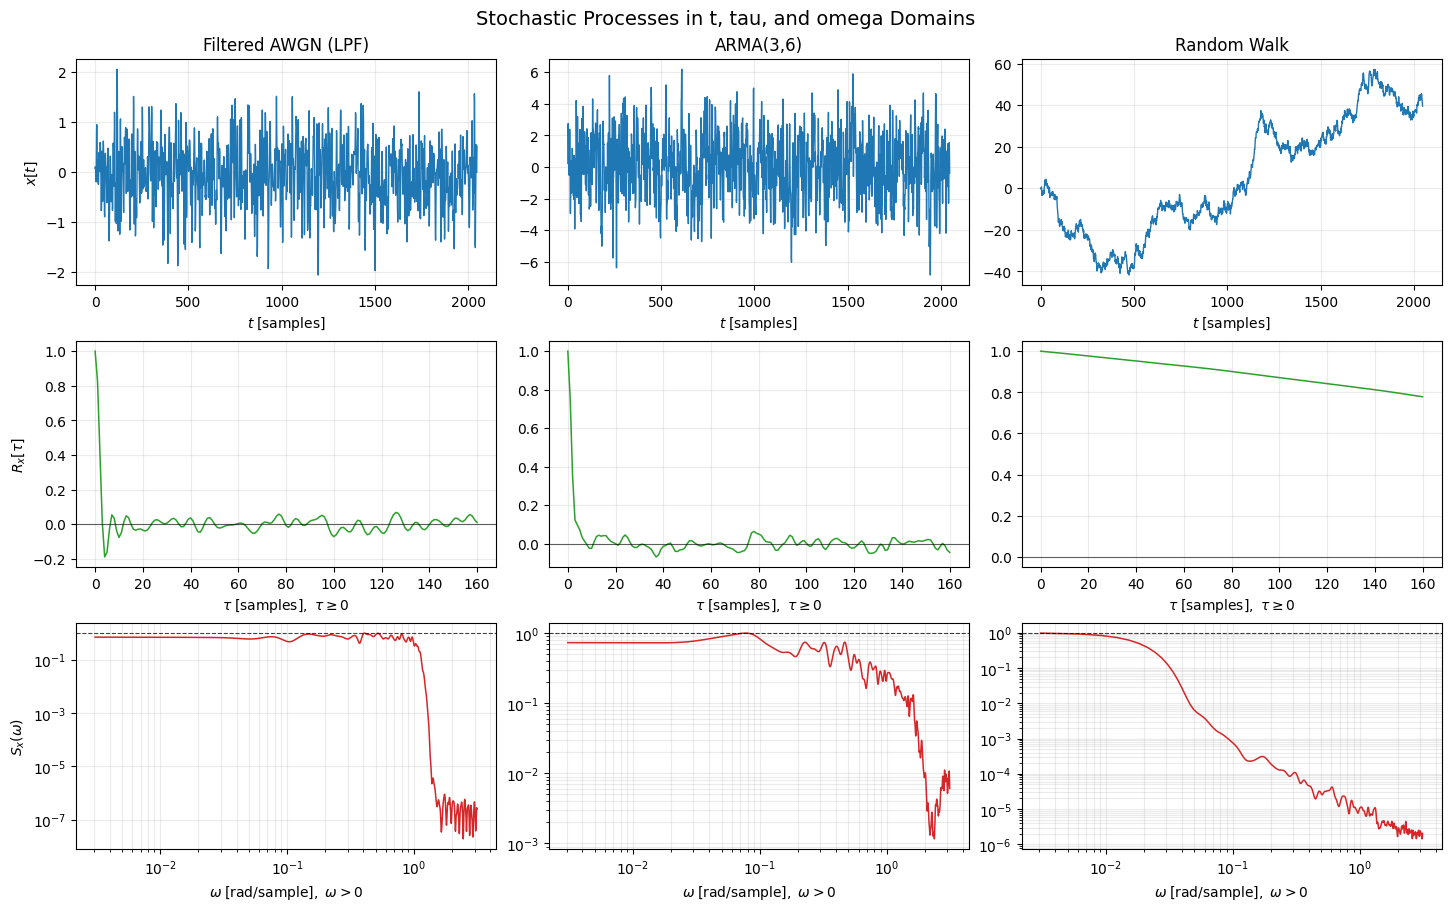

In [13]:
process_names = list(processes.keys())
num_processes = len(process_names)

fig, axes = plt.subplots(
    nrows=3,
    ncols=num_processes,
    figsize=(4.8 * num_processes, 9.0),
    constrained_layout=True,
)

# Keep a 2-D indexing shape even when there is only one process.
if num_processes == 1:
    axes = axes.reshape(3, 1)

for col, process_name in enumerate(process_names):
    process = processes[process_name]

    # Row 1: time-domain realization x[t].
    t_samples = np.arange(process.realization.size)
    ax_t = axes[0, col]
    ax_t.plot(t_samples, process.realization, color="tab:blue", linewidth=1.0)
    ax_t.set_title(process_name)
    ax_t.set_xlabel(r"$t\;[\mathrm{samples}]$")
    if col == 0:
        ax_t.set_ylabel(r"$x[t]$")
    ax_t.grid(alpha=0.25)

    # Row 2: lag-domain autocorrelation R_x[tau] (non-negative lags only).
    tau_samples, acf_values = process.acf
    nonnegative_lag_mask = tau_samples >= 0
    tau_nonnegative = tau_samples[nonnegative_lag_mask]
    acf_nonnegative = acf_values[nonnegative_lag_mask]

    ax_tau = axes[1, col]
    ax_tau.plot(tau_nonnegative, acf_nonnegative, color="tab:green", linewidth=1.1)
    ax_tau.axhline(0.0, color="black", linewidth=0.8, alpha=0.6)
    ax_tau.set_xlabel(r"$\tau\;[\mathrm{samples}],\ \tau \geq 0$")
    if col == 0:
        ax_tau.set_ylabel(r"$R_x[\tau]$")
    ax_tau.grid(alpha=0.25)

    # Row 3: PSD S_x[omega] on log-log axes, positive frequencies only.
    omega_rad, psd_values = process.psd
    positive_freq_mask = omega_rad > 0.0
    omega_pos = omega_rad[positive_freq_mask]
    psd_pos = np.maximum(psd_values[positive_freq_mask], np.finfo(float).eps)

    ax_omega = axes[2, col]
    ax_omega.loglog(omega_pos, psd_pos, color="tab:red", linewidth=1.1)
    # 0 dB corresponds to normalized power level 1.0.
    ax_omega.axhline(1.0, color="black", linestyle="--", linewidth=0.8, alpha=0.75)
    ax_omega.set_xlabel(r"$\omega\;[\mathrm{rad/sample}],\ \omega > 0$")
    if col == 0:
        ax_omega.set_ylabel(r"$S_x(\omega)$")
    ax_omega.grid(alpha=0.25, which="both")

fig.suptitle("Stochastic Processes in t, tau, and omega Domains", fontsize=14)


Given
$$
r_x(\lambda)=\sum_{k=-K}^{K} w_k\,e^{-\alpha_k\lambda^2},\qquad w_k\ge 0,
$$

Is $r_x(\lambda)$ a valid ACF?

For a wide-sense stationary (WSS) process, $r_x(\lambda)$ is a valid ACF **iff** it is positive semidefinite.
By **Bochner's theorem**, this is equivalent to saying its Fourier transform is a nonnegative spectral measure.

consider one term with $\alpha_k>0$:
$$
\mathcal{F}\{e^{-\alpha_k\lambda^2}\}(\omega)
=\sqrt{\frac{\pi}{\alpha_k}}\,e^{-\omega^2/(4\alpha_k)}\ge 0.
$$
Therefore, by linearity,
$$
S_x(\omega)=\mathcal{F}\{r_x(\lambda)\}
=\sum_{k=-K}^{K} w_k\sqrt{\frac{\pi}{\alpha_k}}\,e^{-\omega^2/(4\alpha_k)}\ge 0,
$$
so Wiener-Khinchin gives a valid ACF.

Special cases:
- If some $\alpha_k=0$, the term is constant $w_k$ and contributes $2\pi w_k\delta(\omega)$, still a nonnegative spectral measure.
- If any $\alpha_k<0$, that term grows like $e^{+|\alpha_k|\lambda^2}$, violating the covariance bound $|r_x(\lambda)|\le r_x(0)$, so it cannot be a valid WSS ACF.

**Conclusion:** the proposed form is a valid ACF when all $w_k\ge 0$ and all $\alpha_k\ge 0$ (typically $\alpha_k>0$ for a regular PSD density).



RMSE tolerance for model selection (tau > 0): 1e-08

Filtered AWGN (LPF)
  selection rule: best N within sweep
  N = 2
  RMSE(tau>0) = 0.037862
  RMSE(tau>=0) = 0.037745
  omega_n = [0.0109 0.9891]
  alpha_n = [0.2595 0.2595]

ARMA(3,6)
  selection rule: best N within sweep
  N = 15
  RMSE(tau>0) = 0.024947
  RMSE(tau>=0) = 0.024870
  omega_n = [0.0008 0.0005 0.0006 0.0005 0.0005 0.0005 0.0005 0.0004 0.0003 0.0005
 0.0004 0.0087 0.0087 0.1894 0.7876]
  alpha_n = [0.0028 0.0027 0.0006 0.0002 0.0001 0.0001 0.0001 0.0001 0.0001 0.0003
 0.0004 0.0032 0.0049 0.0751 0.3649]

Random Walk
  selection rule: best N within sweep
  N = 16
  RMSE(tau>0) = 0.000675
  RMSE(tau>=0) = 0.000673
  omega_n = [0.0586 0.0678 0.0801 0.054  0.0614 0.0704 0.0883 0.095  0.0768 0.2287
 0.0247 0.0197 0.0218 0.0198 0.0205 0.0125]
  alpha_n = [0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.0001 0.0001 0.0002 0.0009 0.0108]



{'Filtered AWGN (LPF)': {'N': 2,
  'omega_n': array([0.01091575, 0.98908425]),
  'alpha_n': array([0.25953603, 0.25953603]),
  'mse_all': 0.0014246478919906936,
  'rmse_all': 0.03774450810370555,
  'mse_positive': 0.0014335519413156352,
  'rmse_positive': 0.037862275965869184,
  'selected_by_tolerance': False},
 'ARMA(3,6)': {'N': 15,
  'omega_n': array([7.79705865e-04, 5.25659188e-04, 5.94839383e-04, 5.47359350e-04,
         5.43404975e-04, 4.72971857e-04, 5.42377516e-04, 4.44849124e-04,
         3.09934160e-04, 4.61620897e-04, 3.66880168e-04, 8.65229571e-03,
         8.74989825e-03, 1.89370797e-01, 7.87637406e-01]),
  'alpha_n': array([2.75032682e-03, 2.74075240e-03, 5.69958184e-04, 1.55034380e-04,
         1.00768369e-04, 8.21511987e-05, 8.61708663e-05, 9.93102352e-05,
         1.36899206e-04, 3.09956855e-04, 3.59895104e-04, 3.21363297e-03,
         4.94151822e-03, 7.50667652e-02, 3.64910290e-01]),
  'mse_all': 0.0006184960505565831,
  'rmse_all': 0.024869580827922753,
  'mse_positi

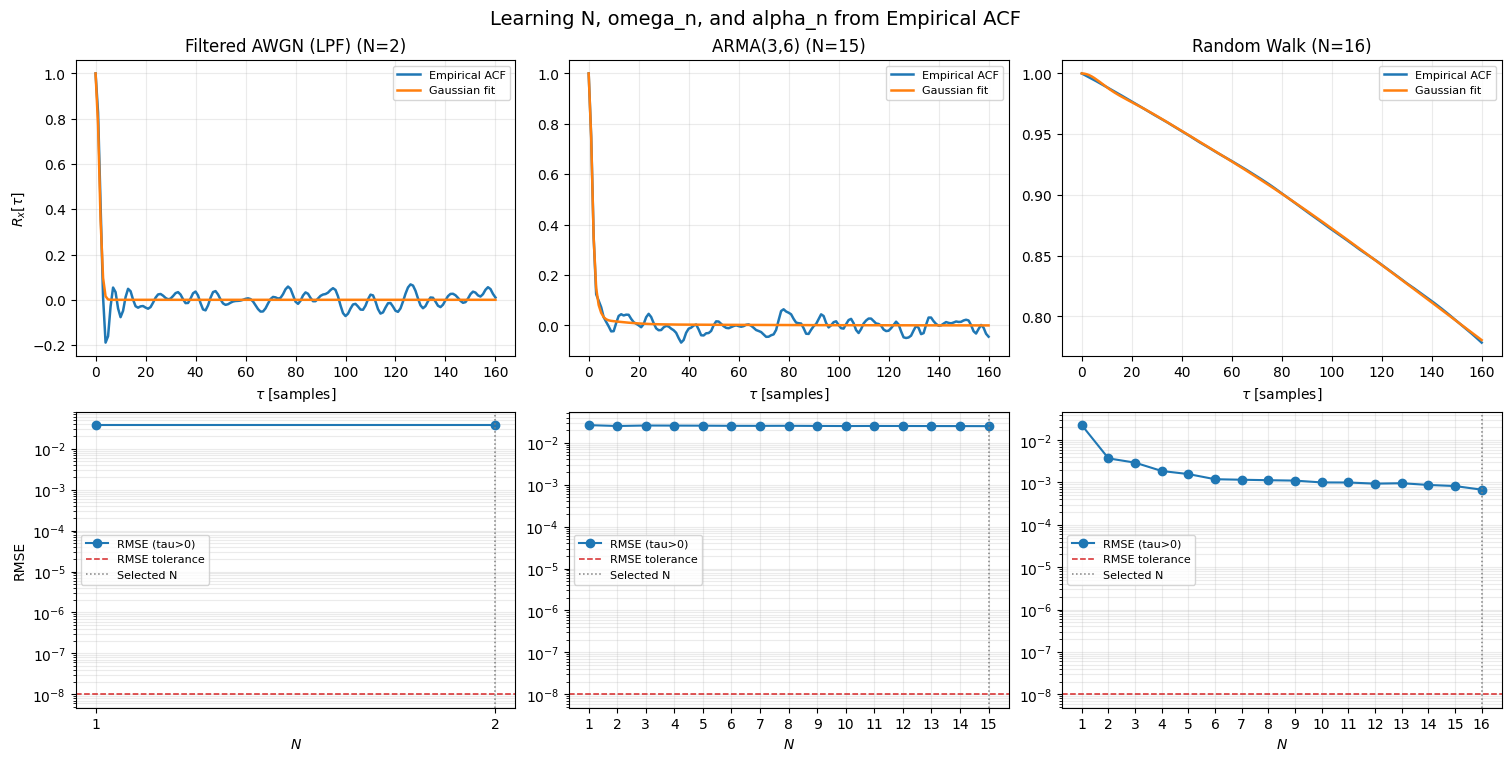

In [14]:
from dataclasses import dataclass


@dataclass(frozen=True)
class GaussianAcfLearningResult:
    """Stores learned Gaussian-mixture ACF parameters for one process."""

    N: int                                  # Selected model order
    omega_n: np.ndarray                     # Nonnegative weights that sum to one
    alpha_n: np.ndarray                     # Positive Gaussian decay rates [1/samples^2]
    mse_all: float                          # MSE on tau >= 0 (used for fit reporting)
    rmse_all: float                         # RMSE on tau >= 0
    mse_positive: float                     # MSE on tau > 0 (used for model selection)
    rmse_positive: float                    # RMSE on tau > 0 (used for model selection)
    tau_samples: np.ndarray                 # Nonnegative lags used for fitting [samples]
    target_acf: np.ndarray                  # Empirical ACF values at tau_samples
    fitted_acf: np.ndarray                  # Model ACF values at tau_samples
    mse_all_per_N: list[float]              # Sweep curve on tau >= 0
    mse_positive_per_N: list[float]         # Sweep curve on tau > 0
    selected_by_tolerance: bool             # True if first N below tolerance was found


def fit_acf_fixed_order(
    tau_samples: np.ndarray,                # Nonnegative lag indices [samples]
    target_acf: np.ndarray,                 # Empirical normalized ACF r_x[tau]
    N: int,                                 # Number of Gaussian components
    num_steps: int = 2500,                  # Gradient steps per restart
    learning_rate: float = 0.04,            # Adam learning rate
    num_restarts: int = 5,                  # Random restarts to reduce local minima risk
    base_seed: int = 1234,                  # Seed base for reproducible optimization
) -> tuple[np.ndarray, np.ndarray, float, float, np.ndarray]:
    """Fit omega_n and alpha_n for a fixed N by minimizing ACF MSE.

    Purpose:
        Solve
            r_hat(tau) = sum_n omega_n * exp(-alpha_n * tau^2)
        under the constraints omega_n >= 0, sum_n omega_n = 1, alpha_n > 0.

        The model is trained with tau >= 0, but model-selection metrics are
        tracked both on tau >= 0 and on tau > 0.

    Parameters:
        tau_samples: Nonnegative lag indices used for learning [samples].
        target_acf: Empirical normalized ACF values at the selected lags.
        N: Number of Gaussian basis functions in the model.
        num_steps: Optimization iterations for each restart.
        learning_rate: Step size for Adam.
        num_restarts: Number of initializations to try; best one is kept.
        base_seed: Deterministic seed base to keep reproducible runs.

    Returns:
        Tuple (omega_n, alpha_n, mse_all, mse_positive, fitted_acf) for the best
        restart according to mse_positive.

    Side effects:
        Uses PyTorch autograd/optimizer but does not mutate global state.

    Assumptions:
        tau_samples are nonnegative and target_acf has matching shape.
    """
    if N < 1:
        raise ValueError('N must be >= 1.')
    if tau_samples.ndim != 1 or target_acf.ndim != 1:
        raise ValueError('tau_samples and target_acf must be 1-D arrays.')
    if tau_samples.shape[0] != target_acf.shape[0]:
        raise ValueError('tau_samples and target_acf must have the same length.')
    if np.any(tau_samples < 0):
        raise ValueError('tau_samples must contain only nonnegative lags.')

    tau_float = tau_samples.astype(np.float64)
    target_float = target_acf.astype(np.float64)

    tau_tensor = torch.as_tensor(tau_float, dtype=torch.float64)
    target_tensor = torch.as_tensor(target_float, dtype=torch.float64)
    tau_squared = tau_tensor**2

    positive_mask_tensor = tau_tensor > 0
    if not bool(torch.any(positive_mask_tensor)):
        positive_mask_tensor = tau_tensor >= 0

    tau_max_samples = max(float(np.max(tau_float)), 1.0)
    alpha_min = 1.0e-7
    alpha_max = max(8.0 / (tau_max_samples**2), 1.0e-3)

    best_mse_positive = float('inf')
    best_omega_n = np.empty(0, dtype=np.float64)
    best_alpha_n = np.empty(0, dtype=np.float64)
    best_mse_all = float('inf')
    best_fitted = np.empty(0, dtype=np.float64)

    # Run multiple restarts and keep the best local optimum by positive-lag MSE.
    for restart_idx in range(num_restarts):
        generator = torch.Generator().manual_seed(base_seed + 997 * N + restart_idx)

        raw_logits = torch.nn.Parameter(
            0.15 * torch.randn(N, dtype=torch.float64, generator=generator)
        )

        # Initialize alpha_n on a log grid to cover both slow and fast decays.
        alpha_grid = torch.logspace(
            np.log10(alpha_min),
            np.log10(alpha_max),
            N,
            dtype=torch.float64,
        )
        alpha_perturbation = 1.0 + 0.2 * torch.randn(N, dtype=torch.float64, generator=generator)
        alpha_init = torch.clamp(alpha_grid * alpha_perturbation, min=alpha_min)
        raw_alpha = torch.nn.Parameter(torch.log(torch.expm1(alpha_init)))

        optimizer = torch.optim.Adam([raw_logits, raw_alpha], lr=learning_rate)

        for _ in range(num_steps):
            optimizer.zero_grad()

            omega_n = torch.softmax(raw_logits, dim=0)
            alpha_n = torch.nn.functional.softplus(raw_alpha) + 1.0e-9

            # Build Gaussian basis over tau and combine it with nonnegative weights.
            basis_matrix = torch.exp(-tau_squared[:, None] * alpha_n[None, :])
            fitted_tensor = basis_matrix @ omega_n

            # Train on tau >= 0 to keep the full ACF fit constrained and stable.
            mse_train_tensor = torch.mean((fitted_tensor - target_tensor) ** 2)

            mse_train_tensor.backward()
            optimizer.step()

        with torch.no_grad():
            omega_n = torch.softmax(raw_logits, dim=0)
            alpha_n = torch.nn.functional.softplus(raw_alpha) + 1.0e-9
            basis_matrix = torch.exp(-tau_squared[:, None] * alpha_n[None, :])
            fitted_tensor = basis_matrix @ omega_n

            residual_tensor = fitted_tensor - target_tensor
            mse_all_value = float(torch.mean(residual_tensor**2).item())
            mse_positive_value = float(torch.mean(residual_tensor[positive_mask_tensor] ** 2).item())

        if mse_positive_value < best_mse_positive:
            best_mse_positive = mse_positive_value
            best_mse_all = mse_all_value
            best_omega_n = omega_n.cpu().numpy()
            best_alpha_n = alpha_n.cpu().numpy()
            best_fitted = fitted_tensor.cpu().numpy()

    return best_omega_n, best_alpha_n, best_mse_all, best_mse_positive, best_fitted


def learn_gaussian_acf_parameters(
    process: StochasticProcess,             # Process realization + ACF/PSD bundle
    N_max: int = 10,                        # Maximum model order considered in sweep
    rmse_tolerance: float = 1e-8,           # Stop criterion on positive-lag RMSE
    num_steps: int = 2500,                  # Optimizer steps per fixed-order fit
    learning_rate: float = 0.04,            # Adam learning rate
    num_restarts: int = 5,                  # Random restarts per fixed N
    base_seed: int = 1234,                  # Reproducibility seed base
) -> GaussianAcfLearningResult:
    """Run K-sweep and learn N, omega_n, and alpha_n for one process.

    Purpose:
        Find the smallest N for which the Gaussian-mixture ACF model satisfies
        a positive-lag RMSE tolerance (tau > 0). If no N satisfies it, keep the
        globally best N among 1..N_max according to positive-lag MSE.

    Parameters:
        process: StochasticProcess instance containing empirical ACF.
        N_max: Maximum candidate order to evaluate.
        rmse_tolerance: Acceptance threshold for sqrt(MSE) on tau > 0.
        num_steps: Optimizer iterations used in each fixed-order fit.
        learning_rate: Adam learning rate for parameter updates.
        num_restarts: Number of random initializations per N.
        base_seed: Seed base for deterministic optimization.

    Returns:
        GaussianAcfLearningResult with selected N and learned parameter vectors.

    Side effects:
        None.

    Assumptions:
        ACF has finite values and includes lag tau=0.
    """
    if N_max < 1:
        raise ValueError('N_max must be >= 1.')
    if rmse_tolerance <= 0.0:
        raise ValueError('rmse_tolerance must be positive.')

    tau_samples_all, acf_all = process.acf
    nonnegative_mask = tau_samples_all >= 0
    tau_nonnegative = tau_samples_all[nonnegative_mask].astype(np.float64)
    acf_nonnegative = np.asarray(acf_all[nonnegative_mask], dtype=np.float64)

    if tau_nonnegative.size == 0:
        raise ValueError('ACF must contain at least one nonnegative lag sample.')

    mse_all_per_N: list[float] = []
    mse_positive_per_N: list[float] = []
    selected_result: GaussianAcfLearningResult | None = None
    best_result: GaussianAcfLearningResult | None = None

    # Sweep model order and stop at the first order satisfying the tolerance.
    for N in range(1, N_max + 1):
        omega_n, alpha_n, mse_all_value, mse_positive_value, fitted_acf = fit_acf_fixed_order(
            tau_samples=tau_nonnegative,
            target_acf=acf_nonnegative,
            N=N,
            num_steps=num_steps,
            learning_rate=learning_rate,
            num_restarts=num_restarts,
            base_seed=base_seed,
        )
        mse_all_per_N.append(mse_all_value)
        mse_positive_per_N.append(mse_positive_value)

        rmse_all_value = float(np.sqrt(mse_all_value))
        rmse_positive_value = float(np.sqrt(mse_positive_value))

        candidate = GaussianAcfLearningResult(
            N=N,
            omega_n=omega_n,
            alpha_n=alpha_n,
            mse_all=mse_all_value,
            rmse_all=rmse_all_value,
            mse_positive=mse_positive_value,
            rmse_positive=rmse_positive_value,
            tau_samples=tau_nonnegative,
            target_acf=acf_nonnegative,
            fitted_acf=fitted_acf,
            mse_all_per_N=mse_all_per_N.copy(),
            mse_positive_per_N=mse_positive_per_N.copy(),
            selected_by_tolerance=rmse_positive_value <= rmse_tolerance,
        )

        if best_result is None or mse_positive_value < best_result.mse_positive:
            best_result = candidate

        if selected_result is None and rmse_positive_value <= rmse_tolerance:
            selected_result = candidate

    if selected_result is not None:
        return selected_result
    assert best_result is not None  # N_max >= 1 guarantees at least one candidate.
    return best_result


# Hyperparameters for learning and model-order selection.
N_max = 25
rmse_tolerance = 1e-8
num_steps = 2500
learning_rate = 0.04
num_restarts = 5
base_seed = 2026

# Learn parameters independently for each stochastic process in the notebook.
learning_results: dict[str, GaussianAcfLearningResult] = {
    process_name: learn_gaussian_acf_parameters(
        process=process,
        N_max=N_max,
        rmse_tolerance=rmse_tolerance,
        num_steps=num_steps,
        learning_rate=learning_rate,
        num_restarts=num_restarts,
        base_seed=base_seed,
    )
    for process_name, process in processes.items()
}

# Create a compact, reusable dictionary with the learned parameters.
learned_parameters = {
    process_name: {
        'N': result.N,
        'omega_n': result.omega_n,
        'alpha_n': result.alpha_n,
        'mse_all': result.mse_all,
        'rmse_all': result.rmse_all,
        'mse_positive': result.mse_positive,
        'rmse_positive': result.rmse_positive,
        'selected_by_tolerance': result.selected_by_tolerance,
    }
    for process_name, result in learning_results.items()
}

print(f'RMSE tolerance for model selection (tau > 0): {rmse_tolerance}\n')
for process_name, result in learning_results.items():
    status_label = 'first N meeting tolerance' if result.selected_by_tolerance else 'best N within sweep'
    omega_str = np.array2string(result.omega_n, precision=4, suppress_small=True)
    alpha_str = np.array2string(result.alpha_n, precision=4, suppress_small=True)

    print(f'{process_name}')
    print(f'  selection rule: {status_label}')
    print(f'  N = {result.N}')
    print(f'  RMSE(tau>0) = {result.rmse_positive:.6f}')
    print(f'  RMSE(tau>=0) = {result.rmse_all:.6f}')
    print(f'  omega_n = {omega_str}')
    print(f'  alpha_n = {alpha_str}')
    print()


process_names = list(learning_results.keys())
num_processes = len(process_names)

fig, axes = plt.subplots(
    nrows=2,
    ncols=num_processes,
    figsize=(5.0 * num_processes, 7.5),
    constrained_layout=True,
)
if num_processes == 1:
    axes = axes.reshape(2, 1)

for col, process_name in enumerate(process_names):
    result = learning_results[process_name]

    # Top row: empirical ACF versus learned Gaussian-mixture fit.
    ax_fit = axes[0, col]
    ax_fit.plot(result.tau_samples, result.target_acf, label='Empirical ACF', linewidth=1.8)
    ax_fit.plot(result.tau_samples, result.fitted_acf, label='Gaussian fit', linewidth=1.8)
    ax_fit.set_title(f"{process_name} (N={result.N})")
    ax_fit.set_xlabel(r'$\tau\;[\mathrm{samples}]$')
    if col == 0:
        ax_fit.set_ylabel(r'$R_x[\tau]$')
    ax_fit.grid(alpha=0.25)
    ax_fit.legend(loc='best', fontsize=8)

    # Bottom row: K-sweep curve on tau>0 and selection threshold.
    ax_err = axes[1, col]
    N_values = np.arange(1, len(result.mse_positive_per_N) + 1)
    rmse_curve_positive = np.sqrt(np.maximum(result.mse_positive_per_N, np.finfo(float).eps))
    ax_err.semilogy(N_values, rmse_curve_positive, marker='o', linewidth=1.5, label='RMSE (tau>0)')
    ax_err.axhline(rmse_tolerance, color='tab:red', linestyle='--', linewidth=1.1, label='RMSE tolerance')
    ax_err.axvline(result.N, color='tab:gray', linestyle=':', linewidth=1.1, label='Selected N')
    ax_err.set_xlabel(r'$N$')
    if col == 0:
        ax_err.set_ylabel('RMSE')
    ax_err.set_xticks(N_values)
    ax_err.grid(alpha=0.25, which='both')
    ax_err.legend(loc='best', fontsize=8)

fig.suptitle('Learning N, omega_n, and alpha_n from Empirical ACF', fontsize=14)

learned_parameters


## Empirical Ergodicity Test for Every Process

Using the same criterion from `notebooks/ergodicity_test.ipynb`, we now test each simulated process with an ensemble matrix $X[i,t]$:

- **Mean criterion:** $\mathbb{E}_i[\hat\mu_i]$ consistency via normalized RMS error.
- **Variance criterion:** $\mathbb{E}_i[\hat\sigma_i^2]$ consistency via normalized absolute error.

A process is labeled **WSS-ergodic (finite-sample heuristic)** when both criteria pass their tolerances.



Expectation-based WSS ergodicity test (from ergodicity_test.ipynb)
num_realizations=256, num_samples=2048
mean_tolerance=0.08, variance_tolerance=0.15

Filtered AWGN (LPF)
  is_wss_ergodic: True
  is_mean_ergodic: True | error=0.038079
  is_variance_ergodic: True | error=0.001450
  global_mean=+0.000372, E_i[mean_t]=+0.000372
  global_var=0.329549, E_i[var_t]=0.329071

ARMA(3,6)
  is_wss_ergodic: True
  is_mean_ergodic: True | error=0.046244
  is_variance_ergodic: True | error=0.002139
  global_mean=-0.007199, E_i[mean_t]=-0.007199
  global_var=3.832774, E_i[var_t]=3.824578

Random Walk
  is_wss_ergodic: False
  is_mean_ergodic: False | error=0.812387
  is_variance_ergodic: False | error=0.659972
  global_mean=-0.218565, E_i[mean_t]=-0.218565
  global_var=907.951569, E_i[var_t]=308.728908



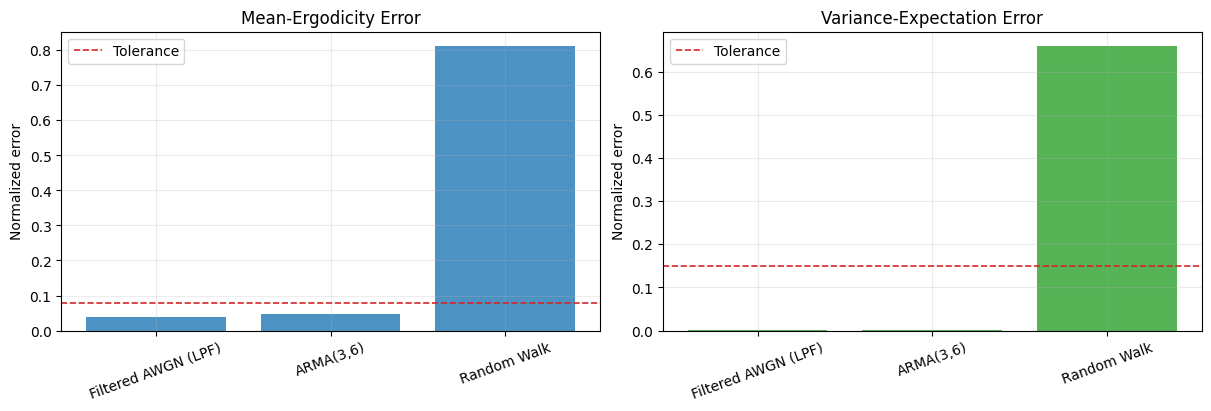

In [15]:
@dataclass(frozen=True)
class WssErgodicityResult:
    """Stores expectation-based finite-sample WSS ergodicity diagnostics."""

    is_wss_ergodic: bool
    is_mean_ergodic: bool
    is_variance_ergodic: bool
    mean_ergodicity_error: float
    variance_expectation_error: float
    global_mean: float
    global_variance: float
    expected_time_mean: float
    expected_time_variance: float


def simulate_process_ensemble(
    specification: ProcessSpecification,     # Process model to simulate
    num_realizations: int,                   # Number of realizations in the ensemble [rows]
    num_samples: int,                        # Number of time samples per realization [samples]
    seed: int = 2026,                        # Deterministic seed for reproducible ensembles
) -> np.ndarray:                             # Ensemble matrix X[i, t]
    """Generate an ensemble matrix for one process specification.

    Purpose:
        Build the row-wise realization matrix required by the ergodicity
        diagnostics from `ergodicity_test.ipynb`.

    Parameters:
        specification: Process model and parameters.
        num_realizations: Number of realizations to simulate (rows), must be >= 2.
        num_samples: Number of samples in each realization [samples], must be >= 2.
        seed: Base seed used for deterministic random generation.

    Returns:
        Array with shape (num_realizations, num_samples), where each row is one
        independent realization simulated from `specification`.

    Side effects:
        None.

    Assumptions:
        `simulate_from_specification` produces one-dimensional realizations with
        exactly `num_samples` samples.
    """
    if num_realizations < 2:
        raise ValueError('num_realizations must be >= 2 for ergodicity testing.')
    if num_samples < 2:
        raise ValueError('num_samples must be >= 2 for ergodicity testing.')

    rng = np.random.default_rng(seed=seed)

    # Simulate each realization independently and stack them as rows.
    realization_rows = [
        simulate_from_specification(
            specification=specification,
            num_samples=num_samples,
            rng=rng,
        )
        for _ in range(num_realizations)
    ]
    return np.vstack(realization_rows).astype(np.float64)


def test_wss_ergodicity(
    signal_matrix: np.ndarray,               # Ensemble matrix X[i, t] (rows=realizations, cols=time)
    mean_tolerance: float = 0.08,            # Threshold for normalized mean-ergodicity error
    variance_tolerance: float = 0.15,        # Threshold for normalized variance expectation error
    eps: float = 1e-8,                       # Numerical stabilization constant
) -> WssErgodicityResult:                    # Structured ergodicity decision and diagnostics
    """Apply the expectation-based WSS ergodicity test from `ergodicity_test.ipynb`.

    Purpose:
        Reproduce the notebook criterion that compares global moments against
        expected time moments across realizations:
        1) normalized RMS spread of per-realization time means,
        2) normalized mismatch between expected time variance and global variance.

    Parameters:
        signal_matrix: 2-D array with shape (num_realizations, num_samples).
        mean_tolerance: Acceptance threshold for mean-ergodicity error.
        variance_tolerance: Acceptance threshold for variance expectation error.
        eps: Positive stabilization term used in normalization denominators.

    Returns:
        WssErgodicityResult containing scalar diagnostics and boolean decisions.

    Side effects:
        None.

    Assumptions:
        Rows correspond to process realizations and columns to time samples.
    """
    if signal_matrix.ndim != 2:
        raise ValueError('signal_matrix must have shape (num_realizations, num_samples).')
    if signal_matrix.shape[0] < 2 or signal_matrix.shape[1] < 2:
        raise ValueError('signal_matrix must contain at least 2 realizations and 2 samples.')
    if mean_tolerance <= 0.0:
        raise ValueError('mean_tolerance must be strictly positive.')
    if variance_tolerance <= 0.0:
        raise ValueError('variance_tolerance must be strictly positive.')
    if eps <= 0.0:
        raise ValueError('eps must be strictly positive.')

    x = np.asarray(signal_matrix, dtype=np.float64)

    # Compute global moments and scales used to normalize finite-sample errors.
    global_mean = float(np.mean(x))
    global_variance = float(np.var(x, ddof=0))
    global_std = float(np.sqrt(max(global_variance, 0.0)))

    # Compute time moments for each realization and their empirical expectations.
    time_mean_per_realization = np.mean(x, axis=1)
    time_var_per_realization = np.var(x, axis=1, ddof=0)
    expected_time_mean = float(np.mean(time_mean_per_realization))
    expected_time_variance = float(np.mean(time_var_per_realization))

    # Evaluate the same normalized errors used in ergodicity_test.ipynb.
    mean_reference = float(np.mean(np.mean(x, axis=0)))
    mean_ergodicity_error = float(
        np.sqrt(np.mean((time_mean_per_realization - mean_reference) ** 2))
        / (global_std + eps)
    )
    variance_expectation_error = float(
        np.abs(expected_time_variance - global_variance) / (abs(global_variance) + eps)
    )

    is_mean_ergodic = mean_ergodicity_error <= mean_tolerance
    is_variance_ergodic = variance_expectation_error <= variance_tolerance

    return WssErgodicityResult(
        is_wss_ergodic=bool(is_mean_ergodic and is_variance_ergodic),
        is_mean_ergodic=bool(is_mean_ergodic),
        is_variance_ergodic=bool(is_variance_ergodic),
        mean_ergodicity_error=mean_ergodicity_error,
        variance_expectation_error=variance_expectation_error,
        global_mean=global_mean,
        global_variance=global_variance,
        expected_time_mean=expected_time_mean,
        expected_time_variance=expected_time_variance,
    )


# Ergodicity test configuration.
num_realizations_ergodicity = 256
mean_tolerance_ergodicity = 0.08
variance_tolerance_ergodicity = 0.15
ergodicity_base_seed = 2026

# Run the same ergodicity criterion for every process in the quiz.
ergodicity_results: dict[str, WssErgodicityResult] = {}
for process_idx, specification in enumerate(process_specifications):
    process_seed = ergodicity_base_seed + 104729 * process_idx
    ensemble_matrix = simulate_process_ensemble(
        specification=specification,
        num_realizations=num_realizations_ergodicity,
        num_samples=num_samples,
        seed=process_seed,
    )
    ergodicity_results[specification.name] = test_wss_ergodicity(
        signal_matrix=ensemble_matrix,
        mean_tolerance=mean_tolerance_ergodicity,
        variance_tolerance=variance_tolerance_ergodicity,
    )

print('Expectation-based WSS ergodicity test (from ergodicity_test.ipynb)')
print(f'num_realizations={num_realizations_ergodicity}, num_samples={num_samples}')
print(f'mean_tolerance={mean_tolerance_ergodicity}, variance_tolerance={variance_tolerance_ergodicity}\n')

for process_name, result in ergodicity_results.items():
    print(process_name)
    print(f'  is_wss_ergodic: {result.is_wss_ergodic}')
    print(f'  is_mean_ergodic: {result.is_mean_ergodic} | error={result.mean_ergodicity_error:.6f}')
    print(
        '  is_variance_ergodic: '
        f'{result.is_variance_ergodic} | error={result.variance_expectation_error:.6f}'
    )
    print(f'  global_mean={result.global_mean:+.6f}, E_i[mean_t]={result.expected_time_mean:+.6f}')
    print(
        '  global_var='
        f'{result.global_variance:.6f}, E_i[var_t]={result.expected_time_variance:.6f}'
    )
    print()

# Visual summary: diagnostic errors versus acceptance thresholds.
process_labels = list(ergodicity_results.keys())
mean_errors = [ergodicity_results[name].mean_ergodicity_error for name in process_labels]
variance_errors = [ergodicity_results[name].variance_expectation_error for name in process_labels]

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.0), constrained_layout=True)

axes[0].bar(process_labels, mean_errors, color='tab:blue', alpha=0.8)
axes[0].axhline(mean_tolerance_ergodicity, color='tab:red', linestyle='--', linewidth=1.2, label='Tolerance')
axes[0].set_title('Mean-Ergodicity Error')
axes[0].set_ylabel('Normalized error')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].bar(process_labels, variance_errors, color='tab:green', alpha=0.8)
axes[1].axhline(
    variance_tolerance_ergodicity,
    color='tab:red',
    linestyle='--',
    linewidth=1.2,
    label='Tolerance',
)
axes[1].set_title('Variance-Expectation Error')
axes[1].set_ylabel('Normalized error')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.show()
